# Call Center Volume Forecasting & Staffing Capacity Model

This notebook forecasts daily call center volume using two approaches (driver-based
regression and SARIMA time series modeling), then converts the forecast into a staffing
capacity plan.

**Note on data:** the dataset below is simulated to mimic realistic call center behavior
(weekly seasonality, holiday spikes, growth trend, noise), since real call center data
isn't publicly available. The modeling approach is the same one used on real volume data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX

np.random.seed(42)
%matplotlib inline

## 1. Simulate a realistic call center volume dataset

Two years of daily data with: an upward business-growth trend, weekly seasonality
(busier on weekdays), a November-December holiday spike, a New Year dip, and random noise.

In [2]:
start_date = pd.Timestamp("2024-01-01")
n_days = 730
dates = pd.date_range(start_date, periods=n_days, freq="D")

t = np.arange(n_days)
trend = 520 + 0.25 * t

dow = dates.dayofweek
weekly_pattern = np.array([1.15, 1.20, 1.10, 1.05, 1.00, 0.55, 0.45])  # Mon..Sun
weekly_factor = weekly_pattern[dow]

month = dates.month
day = dates.day
holiday_factor = np.where((month == 11) | (month == 12), 1.18, 1.0)
newyear_dip = np.where((month == 1) & (day <= 3), 0.6, 1.0)

noise = np.random.normal(0, 18, n_days)

volume = trend * weekly_factor * holiday_factor * newyear_dip + noise
volume = np.round(np.clip(volume, 50, None)).astype(int)

df = pd.DataFrame({"date": dates, "calls": volume}).set_index("date")
df.head()

,calls
date,
2024-01-01,368
2024-01-02,372
2024-01-03,355
2024-01-04,574
2024-01-05,517


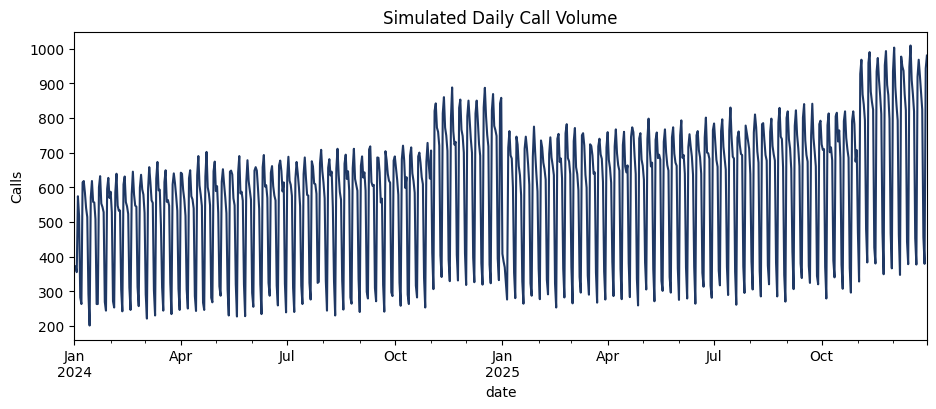

In [3]:
df["calls"].plot(figsize=(11,4), title="Simulated Daily Call Volume", color="#1F3864")
plt.ylabel("Calls")
plt.show()

## 2. Train/test split

We hold out the last 30 days to evaluate forecast accuracy, just like you would in a real
forecasting workflow.

In [4]:
horizon = 30
train, test = df.iloc[:-horizon], df.iloc[-horizon:]
print(f"Train: {train.index.min().date()} to {train.index.max().date()}")
print(f"Test:  {test.index.min().date()} to {test.index.max().date()}")

Train: 2024-01-01 to 2025-11-30
Test:  2025-12-01 to 2025-12-30


## 3. Time series decomposition

Breaking the series into trend, weekly seasonality, and residual noise helps confirm what
patterns are actually present before choosing a model.

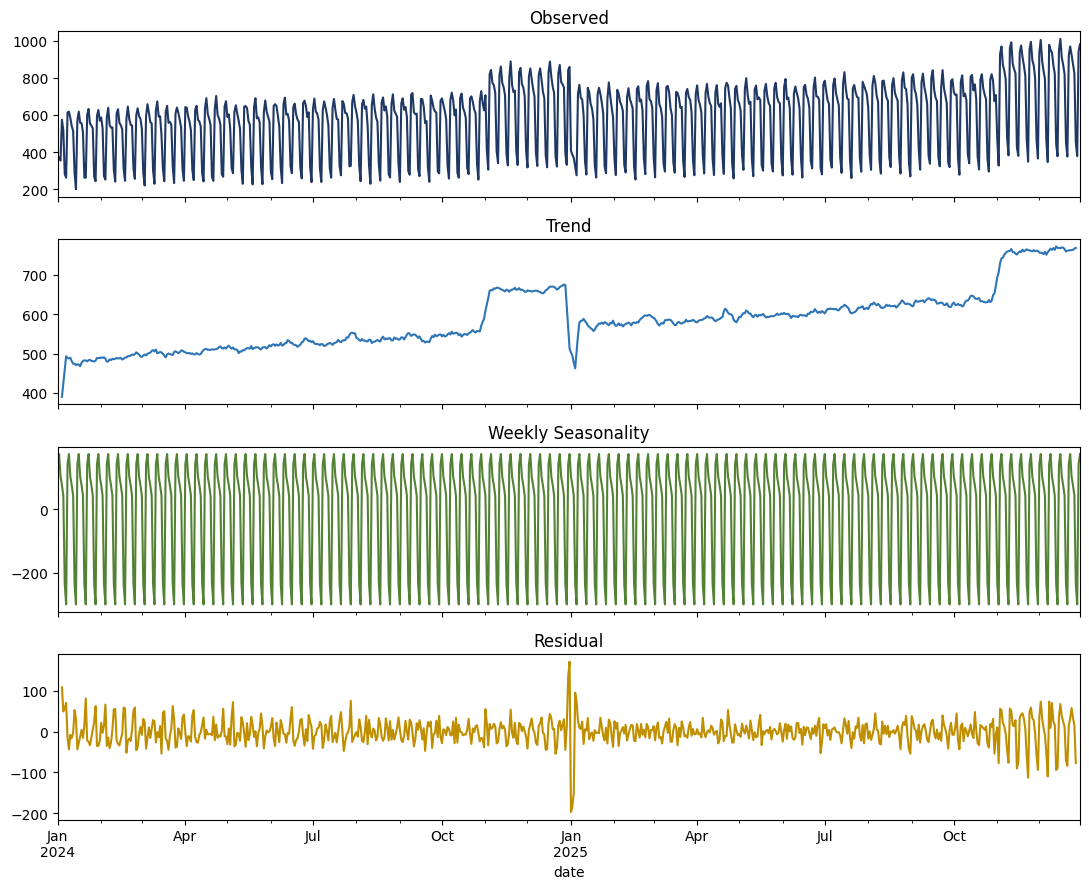

In [5]:
decomp = seasonal_decompose(df["calls"], model="additive", period=7)
fig, axes = plt.subplots(4, 1, figsize=(11, 9), sharex=True)
decomp.observed.plot(ax=axes[0], color="#1F3864"); axes[0].set_title("Observed")
decomp.trend.plot(ax=axes[1], color="#2E75B6"); axes[1].set_title("Trend")
decomp.seasonal.plot(ax=axes[2], color="#548235"); axes[2].set_title("Weekly Seasonality")
decomp.resid.plot(ax=axes[3], color="#BF8F00"); axes[3].set_title("Residual")
plt.tight_layout()
plt.show()

## 4. Driver-based regression model

Features: day-of-week dummies, a linear trend index, and holiday/New Year flags. This
model is interpretable — each coefficient tells you exactly how much that factor moves
call volume.

In [6]:
def make_features(idx):
    f = pd.DataFrame(index=idx)
    f["trend_idx"] = np.array([df.index.get_loc(d) for d in idx])
    for d in range(7):
        f[f"dow_{d}"] = (idx.dayofweek == d).astype(int)
    f["is_holiday_season"] = ((idx.month == 11) | (idx.month == 12)).astype(int)
    f["is_new_year"] = ((idx.month == 1) & (idx.day <= 3)).astype(int)
    return f.drop(columns=["dow_6"])

X_train, X_test = make_features(train.index), make_features(test.index)
y_train, y_test = train["calls"], test["calls"]

reg = LinearRegression().fit(X_train, y_train)
reg_pred = reg.predict(X_test)

reg_mae = mean_absolute_error(y_test, reg_pred)
reg_rmse = mean_squared_error(y_test, reg_pred) ** 0.5
reg_mape = float(np.mean(np.abs((y_test - reg_pred) / y_test)) * 100)
print(f"Regression -> MAE: {reg_mae:.1f} | RMSE: {reg_rmse:.1f} | MAPE: {reg_mape:.1f}%")

Regression -> MAE: 52.7 | RMSE: 58.4 | MAPE: 8.5%


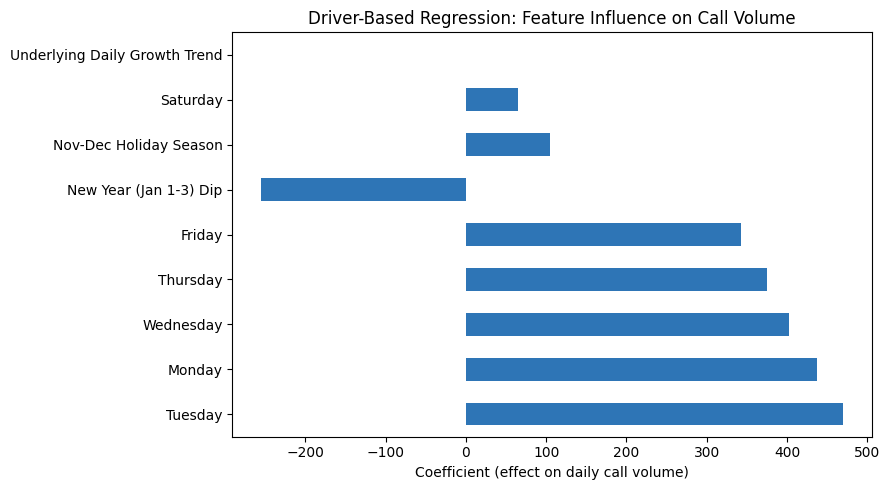

In [7]:
DAY_NAMES = {f"dow_{i}": d for i, d in enumerate(
    ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday"])}
coef_table = pd.Series(reg.coef_, index=X_train.columns).sort_values(key=abs, ascending=False)
coef_table = coef_table.rename(index=lambda k: DAY_NAMES.get(k, k)).rename(index={
    "is_holiday_season": "Nov-Dec Holiday Season",
    "is_new_year": "New Year (Jan 1-3) Dip",
    "trend_idx": "Underlying Daily Growth Trend",
})
coef_table.plot(kind="barh", figsize=(9,5), color="#2E75B6",
                 title="Driver-Based Regression: Feature Influence on Call Volume")
plt.xlabel("Coefficient (effect on daily call volume)")
plt.tight_layout()
plt.show()

## 5. SARIMA time series model

SARIMA learns the seasonal pattern directly from the sequence of past values, without
needing hand-built features. `order=(1,1,1)` and `seasonal_order=(1,1,1,7)` reflect one
round of differencing plus a 7-day (weekly) seasonal cycle.

In [8]:
sarima = SARIMAX(y_train, order=(1,1,1), seasonal_order=(1,1,1,7),
                  enforce_stationarity=False, enforce_invertibility=False)
sarima_fit = sarima.fit(disp=False)
sarima_pred = sarima_fit.forecast(steps=horizon)

sar_mae = mean_absolute_error(y_test, sarima_pred)
sar_rmse = mean_squared_error(y_test, sarima_pred) ** 0.5
sar_mape = float(np.mean(np.abs((y_test - sarima_pred) / y_test)) * 100)
print(f"SARIMA -> MAE: {sar_mae:.1f} | RMSE: {sar_rmse:.1f} | MAPE: {sar_mape:.1f}%")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


SARIMA -> MAE: 30.9 | RMSE: 38.0 | MAPE: 5.6%


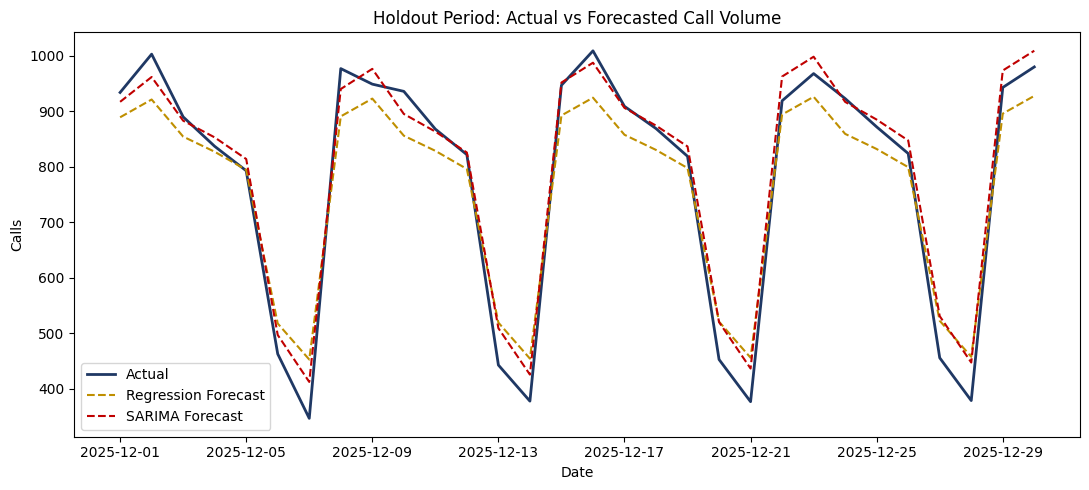

In [9]:
plt.figure(figsize=(11,5))
plt.plot(test.index, y_test, label="Actual", color="#1F3864", linewidth=2)
plt.plot(test.index, reg_pred, label="Regression Forecast", color="#BF8F00", linestyle="--")
plt.plot(test.index, sarima_pred, label="SARIMA Forecast", color="#C00000", linestyle="--")
plt.title("Holdout Period: Actual vs Forecasted Call Volume")
plt.xlabel("Date"); plt.ylabel("Calls"); plt.legend(); plt.tight_layout()
plt.show()

**Takeaway:** SARIMA typically edges out the regression model here because it captures
the seasonal cycle more flexibly. The regression model trades a bit of accuracy for much
better interpretability — you can directly say *why* volume moved.

## 6. Forecasting forward + converting to a staffing plan

Now we forecast 30 days beyond the available data and convert the volume forecast into a
staffing number using a simplified capacity formula:

```
Required Agents = (Forecasted Calls x Average Handle Time) / (Shift Length x Target Occupancy)
```

This is a simplified stand-in for the Erlang-C formula real workforce management teams use,
which additionally models queuing probability and service-level targets.

In [10]:
future_dates = pd.date_range(df.index[-1] + pd.Timedelta(days=1), periods=horizon, freq="D")
sarima_full = SARIMAX(df["calls"], order=(1,1,1), seasonal_order=(1,1,1,7),
                       enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
future_forecast = sarima_full.forecast(steps=horizon)

AHT_SECONDS = 360
WORKDAY_SECONDS = 8 * 3600
TARGET_OCCUPANCY = 0.85

required_fte = (future_forecast * AHT_SECONDS) / (WORKDAY_SECONDS * TARGET_OCCUPANCY)
staffing_df = pd.DataFrame({"forecast_calls": future_forecast.round(0),
                             "required_fte": required_fte.round(1)}, index=future_dates)
staffing_df.head(10)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


,forecast_calls,required_fte
2025-12-31,909.0,13.4
2026-01-01,866.0,12.7
2026-01-02,823.0,12.1
2026-01-03,478.0,7.0
2026-01-04,394.0,5.8
2026-01-05,954.0,14.0
2026-01-06,991.0,14.6
2026-01-07,918.0,13.5
2026-01-08,874.0,12.9
2026-01-09,830.0,12.2


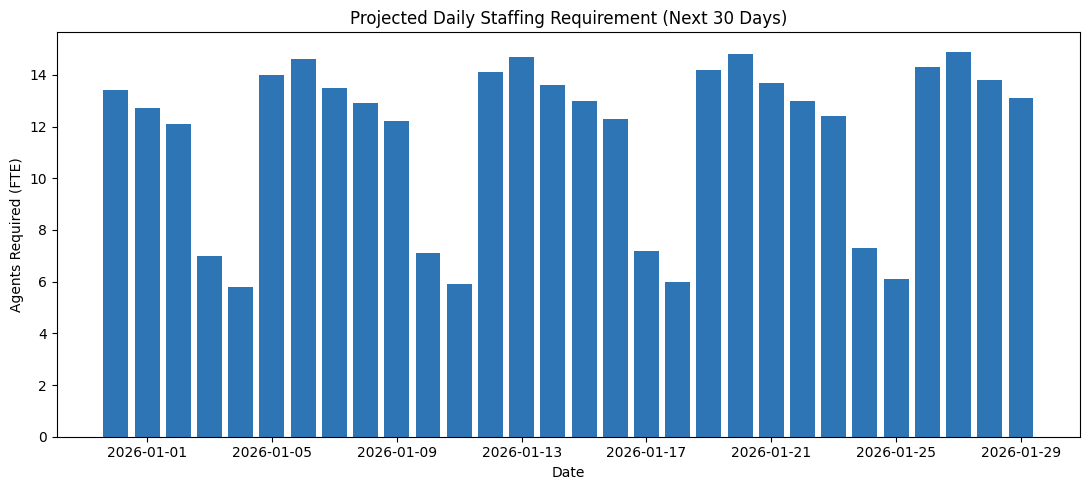

In [11]:
plt.figure(figsize=(11,5))
plt.bar(staffing_df.index, staffing_df["required_fte"], color="#2E75B6")
plt.title("Projected Daily Staffing Requirement (Next 30 Days)")
plt.xlabel("Date"); plt.ylabel("Agents Required (FTE)")
plt.tight_layout()
plt.show()

## 7. Summary

- Decomposition confirmed strong weekly seasonality and a gradual growth trend.
- SARIMA outperformed driver-based regression on holdout accuracy (lower MAPE), while
  regression remained more interpretable for explaining *why* volume moves.
- The volume forecast was converted into a daily staffing requirement using a simplified
  occupancy-based formula, demonstrating the link between forecasting and workforce
  capacity planning.

**Limitations:** this uses simulated data and a simplified staffing formula rather than
full Erlang-C queuing math. Next step for a production version: validate against real
volume data and replace the staffing formula with Erlang-C, which also models service-level
targets and abandonment risk.